<a href="https://colab.research.google.com/github/SSK-KGP/ReLeaf/blob/main/Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Drive

In [ ]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
BASE_PATH = '/content/drive/MyDrive/PlantVillage/'
os.makedirs(BASE_PATH, exist_ok=True)

Mounted at /content/drive


Defining Hyperparameters

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
SEED = 42
BATCH_SIZE = 16
KERAS_MODEL = BASE_PATH + "best_plant_disease_cnn.keras"
LABELS_SAVE = BASE_PATH + "class_names.json"
DATA_SUBDIR = "color"

Unzip the data and store its directory

In [ ]:
shutil.unpack_archive(os.path.join(BASE_PATH, "plant_data.zip"), "/content/plantvillage_dataset")

In [ ]:
data_dir = os.path.join("/content/plantvillage_dataset", "plantvillage dataset", DATA_SUBDIR)

Validation data and rescaling

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

for gpu in tf.config.list_physical_devices('GPU'):
  tf.config.experimental.set_memory_growth(gpu, True)

model = tf.keras.models.load_model(KERAS_MODEL)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split = 0.2, subset = "validation",
    seed = SEED, image_size = (IMG_HEIGHT, IMG_WIDTH), batch_size = BATCH_SIZE
)

with open(LABELS_SAVE, 'r') as f:
  CLASS_NAMES = json.load(f)

Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

rescale = layers.Rescaling(1.0 / 255)

AUTOTUNE = tf.data.AUTOTUNE

val_ds = (val_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls = AUTOTUNE).prefetch(AUTOTUNE))

Confusion Matrix and Classification Report

Val_Loss = 0.4257 | Val_Acc = 86.45%
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.81      0.70      0.75       126
                                 Apple___Black_rot       0.77      0.80      0.79       132
                          Apple___Cedar_apple_rust       0.84      0.98      0.91        55
                                   Apple___healthy       0.61      0.98      0.76       329
                               Blueberry___healthy       0.85      0.87      0.86       295
          Cherry_(including_sour)___Powdery_mildew       0.97      0.87      0.92       232
                 Cherry_(including_sour)___healthy       0.82      0.93      0.87       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.61      0.74       108
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       219
               Corn_(maize)___Northern_Lea

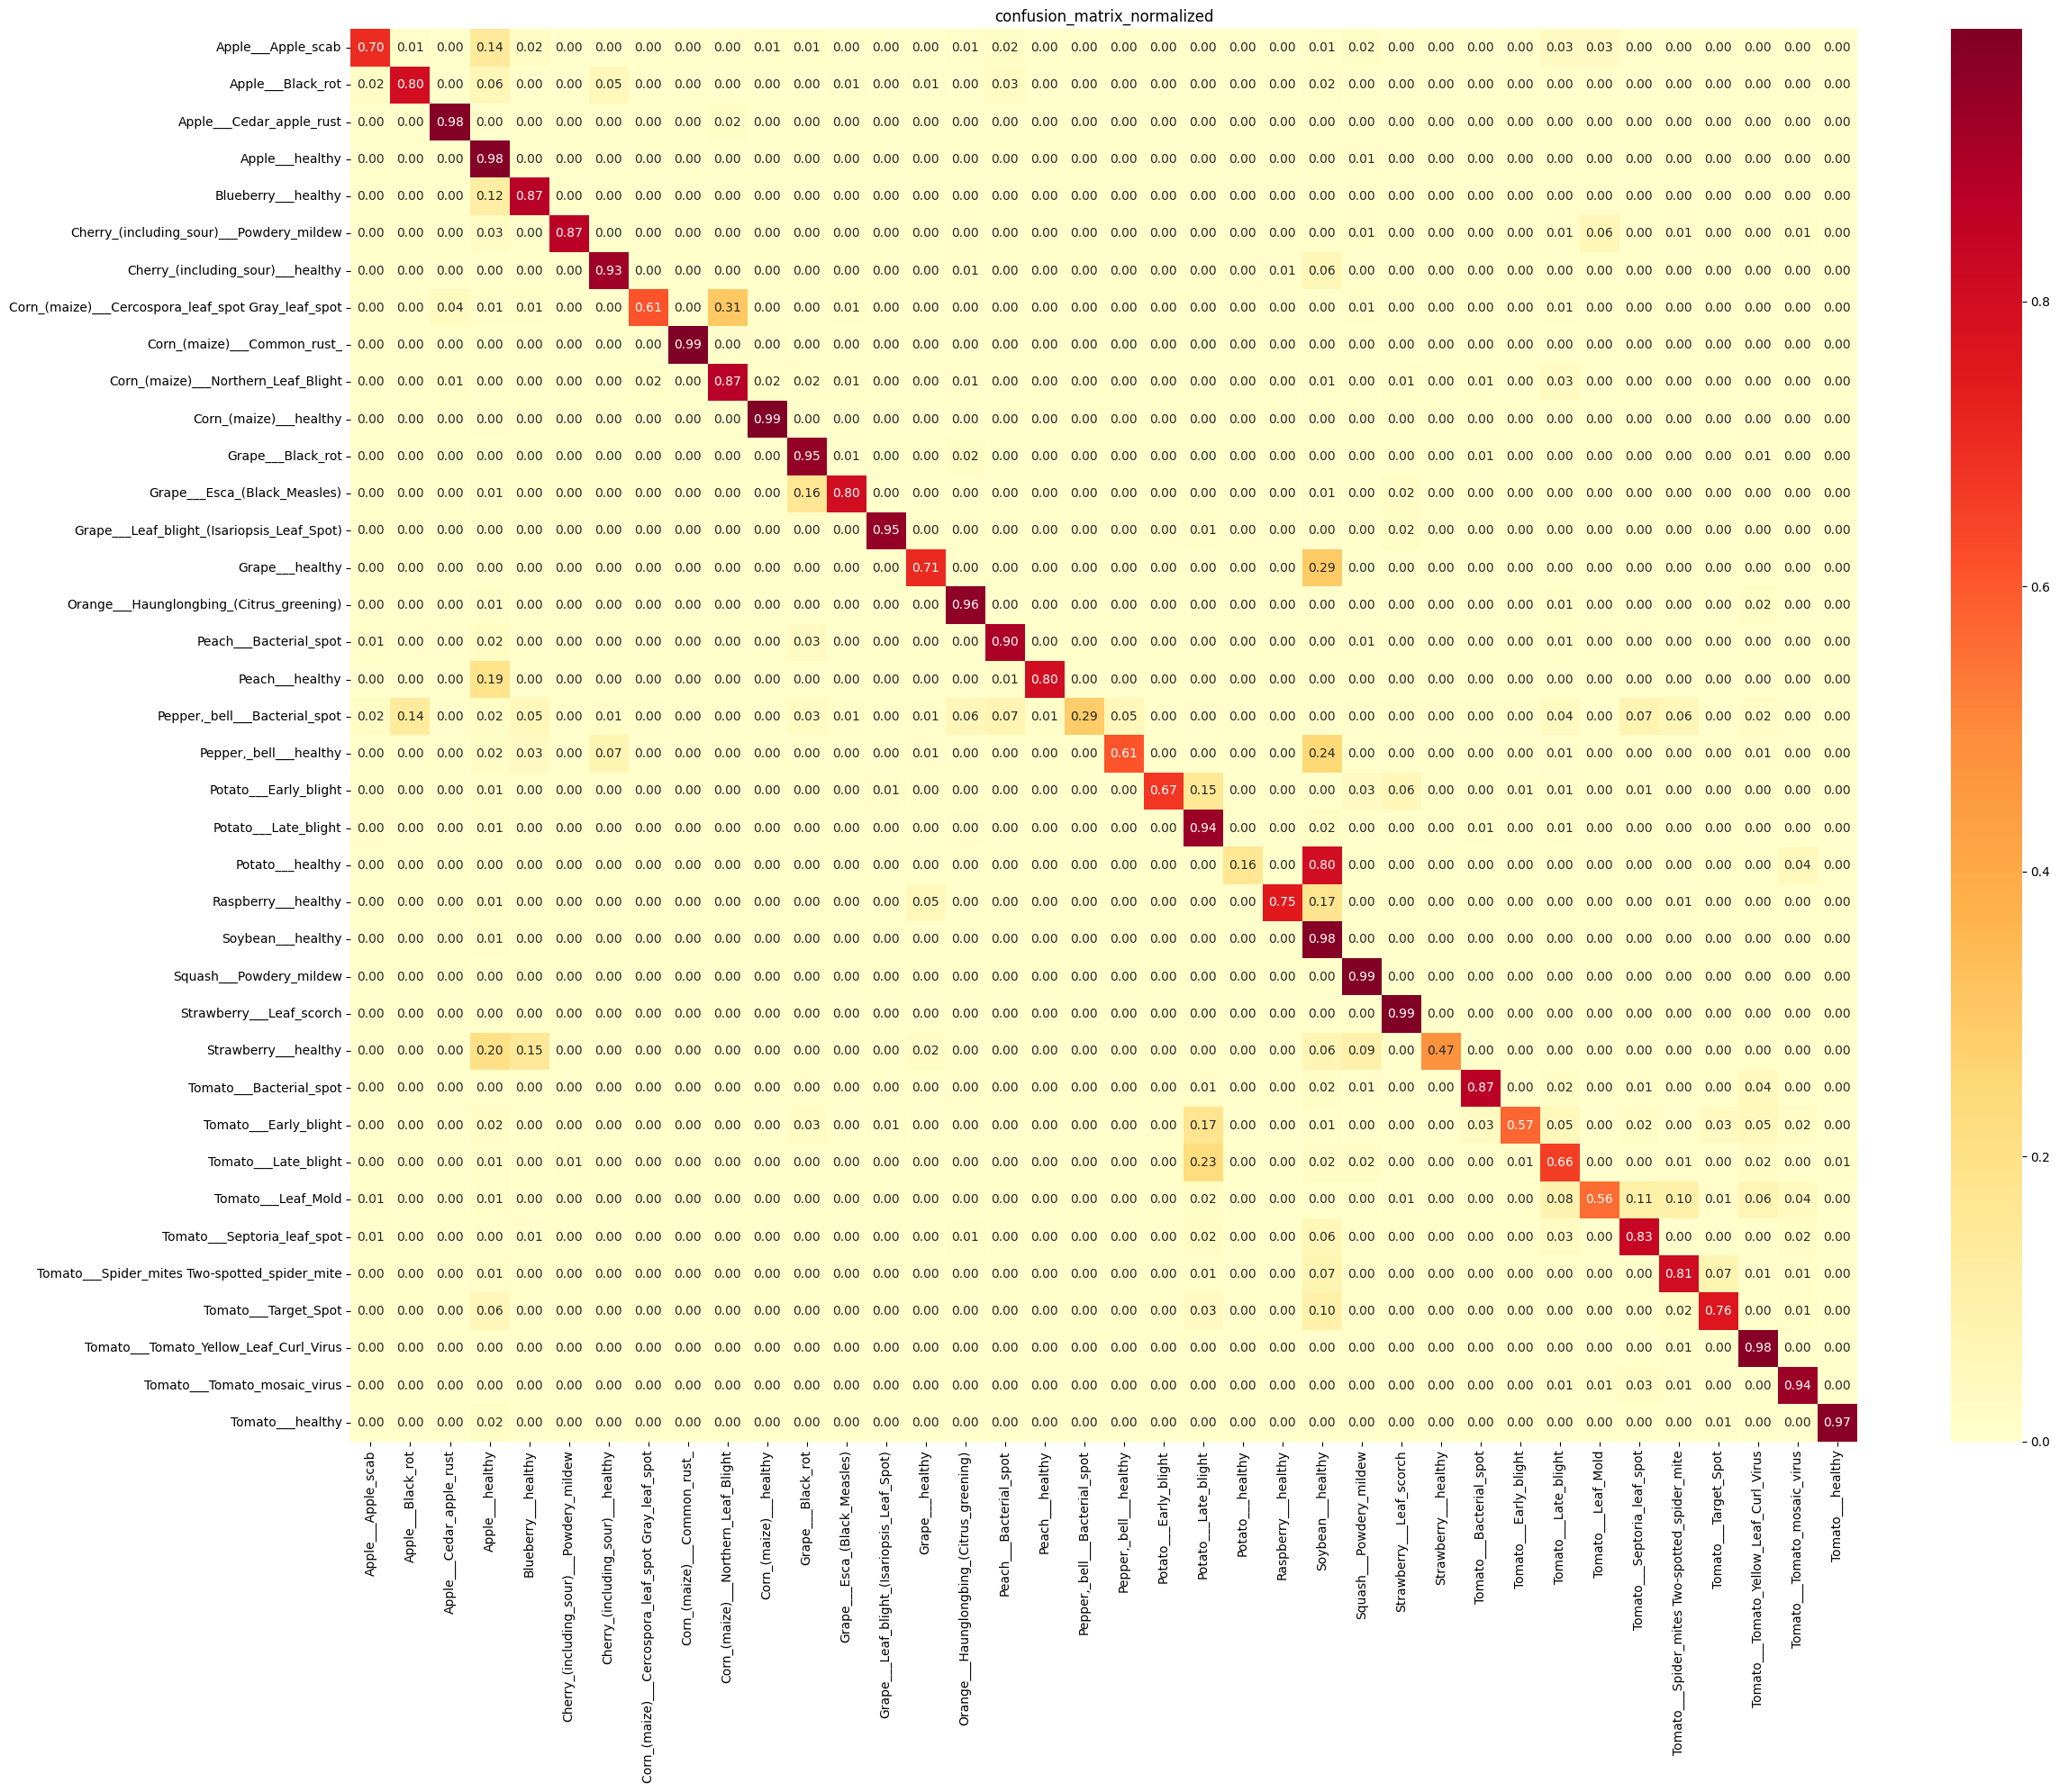

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model = tf.keras.models.load_model(KERAS_MODEL)

val_loss, val_accuracy = model.evaluate(val_ds, verbose = 0)
print(f"Val_Loss = {val_loss:.4f} | Val_Acc = {val_accuracy * 100:.2f}%")

y_true, y_pred, y_proba = [], [], []
for imgs, lbls in val_ds:
  y_true.extend(lbls.numpy())
  y_pred.extend(np.argmax(model.predict(imgs, verbose = 0), axis = 1))
  y_proba.extend(model.predict(imgs, verbose = 0))
y_true, y_pred = np.array(y_true), np.array(y_pred)
print(classification_report(y_true, y_pred, target_names = CLASS_NAMES))

with open(BASE_PATH + "model_classification_report.txt", "w") as f:
  f.write(classification_report(y_true, y_pred, target_names = CLASS_NAMES))

NUM_CLASSES = len(CLASS_NAMES)
if NUM_CLASSES <= 40:
  cm = confusion_matrix(y_true, y_pred, normalize = "true")
  plt.figure(figsize = (25, 20))
  sns.heatmap(cm, annot = True, fmt = ".2f", cmap = "YlOrRd", xticklabels = CLASS_NAMES, yticklabels = CLASS_NAMES)
  plt.title("confusion_matrix_normalized")
  plt.tight_layout()
  plt.savefig(BASE_PATH + "confusion_matrix_normalized.png", dpi = 100)

ROC-curve and PR-curve

roc_auc_score = 1.00


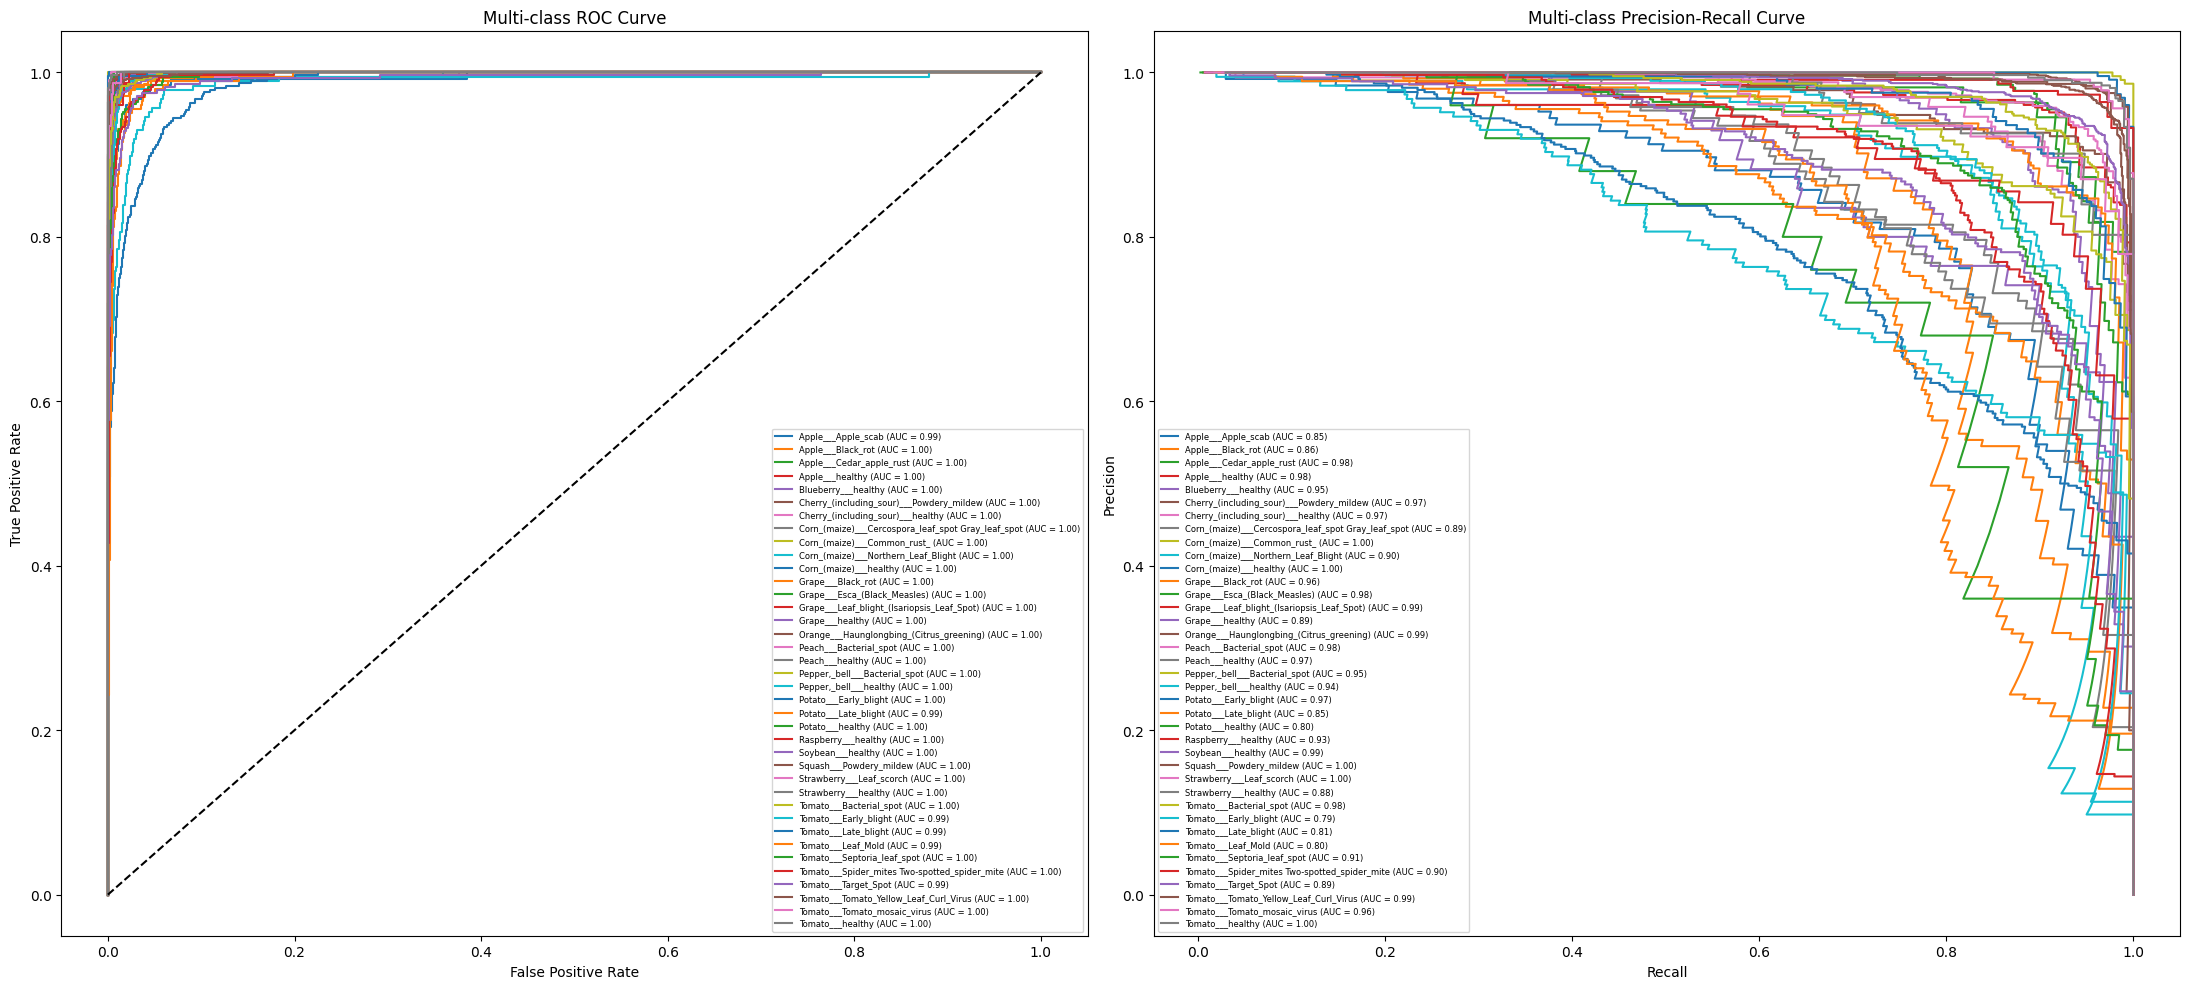

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, auc, precision_recall_curve, average_precision_score

y_proba = np.array(y_proba)
model_roc = roc_auc_score(y_true, y_proba, multi_class = "ovr")
print(f"roc_auc_score = {model_roc:.2f}")

fig, axes = plt.subplots(1, 2, figsize = (22, 10))
for i, c in enumerate(CLASS_NAMES):
  fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_proba[:, i])
  roc_auc = auc(fpr, tpr)
  axes[0].plot(fpr, tpr, label = f"{c} (AUC = {roc_auc:.2f})")

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title("Multi-class ROC Curve")
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

axes[0].legend(loc = 'lower right', fontsize = 6)

for i, c in enumerate(CLASS_NAMES):
  precision, recall, _ = precision_recall_curve((y_true == i).astype(int), y_proba[:, i])
  avg_p = average_precision_score((y_true == i).astype(int), y_proba[:, i])
  axes[1].plot(precision, recall, label = f"{c} (AUC = {avg_p:.2f})")

axes[1].set_title("Multi-class Precision-Recall Curve")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

axes[1].legend(loc = 'lower left', fontsize = 6)

plt.tight_layout()
plt.savefig(BASE_PATH + "roc_pr_curve.png", dpi = 100)